# 네트워크 침입 탐지 — 교차 모델 확률 앙상블 v14

## 가설

서로 다른 오류 구조를 가진 v11 계층형 모델과 첨부 노트북 계열의 RandomForest/XGBoost/LightGBM/계층형 LightGBM 확률을 결합하면, 단일 모델보다 전체 공격 분류와 Infilteration을 동시에 안정적으로 개선할 수 있다.

- 이전 가설의 임계값이나 선택 결과를 정답처럼 재사용하지 않고 각 모델의 **클래스별 확률**만 사용한다.
- 동일한 250,000행, 클래스별 시간순 80/20 외부 검증을 사용한다.
- 외부 검증의 앞 절반에서만 비음수 가중치와 Infilteration 보정계수를 선택한다.
- 뒤 절반은 선택에 사용하지 않는 late holdout으로 남긴다.
- 실시간 rolling feature service가 없으므로 결과가 좋아도 Registry 자동 승격은 하지 않는다.


In [1]:
from pathlib import Path
import gc
import json
import os
import sys
import time
import warnings

import duckdb
import matplotlib.pyplot as plt
import mlflow
import mlflow.pyfunc
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from mlflow.models import infer_signature
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, log_loss, precision_recall_fscore_support
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 160)

cwd = Path.cwd()
PROJECT_DIR = cwd.parent if cwd.name == "notebooks" else cwd
sys.path.insert(0, str(PROJECT_DIR / "src"))
from attached_temporal_features import ROLLING_SOURCE_COLUMNS, build_attachment_feature_frame
from attached_temporal_model import HierarchicalClassifier
from probability_ensemble_model import ProbabilityEnsembleIDSModel
from mlflow_workflow import PROJECT_EXPERIMENT, VALIDATION_COHORT_ID, configure_tracking, file_sha256, hypothesis_run, log_dataframe_input

HYPOTHESIS_ID = "v14"
HYPOTHESIS = "cross_model_probability_ensemble"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_BASE = Path("/home/jovyan/work/datasets")
raw_matches = sorted(DATA_BASE.glob("*/interim/train.parquet"))
processed_matches = sorted(DATA_BASE.glob("*/processed/train_temporal_v5.parquet"))
if len(raw_matches) != 1 or len(processed_matches) != 1:
    raise RuntimeError(f"Dataset resolution failed: raw={raw_matches}, processed={processed_matches}")
RAW_TRAIN = raw_matches[0]
TRAIN_TEMPORAL = processed_matches[0]
OUTPUT_DIR = PROJECT_DIR / "outputs" / HYPOTHESIS_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ID_COL, TARGET, TIMESTAMP = "unique_id", "Label", "Timestamp"
CAT_FEATURES = ["Dst Port", "Protocol"]
CALENDAR_FEATURES = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "elapsed_hours"]
TRAIN_SAMPLE = 250_000
OUTER_VALID_FRACTION = 0.20
V11_GATE_URI = "models:/m-71ffa045d7044cbc95e2eb627309f60a"
V11_SUBTYPE_URI = "models:/m-1eb20bbb39f34e22898c392191eaf13b"

REQUESTED_FLOW_FEATURES = [
    "Flow Duration", "Flow IAT Min", "Flow IAT Mean", "Flow IAT Std",
    "Pkt Len Std", "Pkt Size Avg", "Init Fwd Win Byts", "Subflow Fwd Byts",
    "ACK Flag Cnt", "SYN Flag Cnt", "PSH Flag Cnt", "Dst Port",
    "TotLen Fwd Pkts", "Active Mean",
]
V11_BASELINE = {"weighted_f1_attacks": 0.9202635317983452, "macro_f1_attacks": 0.7542085463961232, "accuracy": 0.9018564455469312, "infilteration_precision": 0.0912707699508542, "infilteration_recall": 0.5019305019305019, "infilteration_f1": 0.15445544554455445, "benign_to_infilteration_fp": 3883}
V13_BASELINE = {"weighted_f1_attacks": 0.9562218326752184, "macro_f1_attacks": 0.7915171561291683, "accuracy": 0.9240217652236536, "infilteration_precision": 0.10510752688172043, "infilteration_recall": 0.5032175032175032, "infilteration_f1": 0.1738937069157216, "benign_to_infilteration_fp": 3329}

MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://mlflow:5000")
experiment_id = configure_tracking(MLFLOW_TRACKING_URI, PROJECT_EXPERIMENT)
print("Experiment:", PROJECT_EXPERIMENT, experiment_id)
print("Raw / processed:", RAW_TRAIN, TRAIN_TEMPORAL)
print("Output:", OUTPUT_DIR)


Experiment: network-classification-ids 1
Raw / processed: /home/jovyan/work/datasets/ 📁 network-classification/interim/train.parquet /home/jovyan/work/datasets/ 📁 network-classification/processed/train_temporal_v5.parquet
Output: /home/jovyan/work/network-classification/outputs/v14


## 1. 동일 표본 정렬 및 두 피처 공간 생성

In [2]:
def parquet_expr(path):
    return f"read_parquet('{str(path).replace(chr(39), chr(39) * 2)}')"

def add_ids_features(frame):
    frame = frame.copy()
    flags = ["SYN Flag Cnt", "ACK Flag Cnt", "RST Flag Cnt", "FIN Flag Cnt", "URG Flag Cnt", "PSH Flag Cnt"]
    values = {column: pd.to_numeric(frame[column], errors="coerce").fillna(0).astype(float) for column in flags}
    syn, ack, rst, fin, urg, psh = (values[column] for column in flags)
    total = syn + ack + rst + fin + urg + psh + 1.0
    frame["SYN_ACK_ratio"] = (syn + 1) / (ack + 1)
    frame["RST_ACK_ratio"] = (rst + 1) / (ack + 1)
    frame["SYN_RST_over_ACK_FIN"] = (syn + rst + 1) / (ack + fin + 1)
    frame["ACK_SYN_ratio"] = (ack + 1) / (syn + 1)
    frame["URG_ACK_ratio"] = (urg + 1) / (ack + 1)
    frame["SYN_share"] = (syn + 1) / total
    frame["RST_share"] = (rst + 1) / total
    numeric = frame.select_dtypes(include=[np.number]).columns
    frame[numeric] = frame[numeric].replace([np.inf, -np.inf], np.nan)
    return frame

with duckdb.connect() as connection:
    processed_sample = connection.execute(f'''
        SELECT * FROM {parquet_expr(TRAIN_TEMPORAL)}
        USING SAMPLE reservoir({TRAIN_SAMPLE} ROWS) REPEATABLE ({RANDOM_STATE})
    ''').df()
    available = connection.execute(f"DESCRIBE SELECT * FROM {parquet_expr(RAW_TRAIN)}").df()["column_name"].tolist()
    selected_flow_features = [column for column in REQUESTED_FLOW_FEATURES if column in available]
    missing_flow_features = [column for column in REQUESTED_FLOW_FEATURES if column not in available]
    required = list(dict.fromkeys([ID_COL, TARGET, *ROLLING_SOURCE_COLUMNS, *selected_flow_features]))
    quoted = ", ".join(f'"{column}"' for column in required)
    full_raw = connection.execute(f"SELECT {quoted} FROM {parquet_expr(RAW_TRAIN)} ORDER BY {TIMESTAMP}, {ID_COL}").df()

full_raw[TIMESTAMP] = pd.to_datetime(full_raw[TIMESTAMP])
sample_ids = set(processed_sample[ID_COL].tolist())
sample_mask = full_raw[ID_COL].isin(sample_ids)
sample_meta = full_raw.loc[sample_mask, [ID_COL, TIMESTAMP, TARGET]].reset_index(drop=True)
assert len(sample_meta) == TRAIN_SAMPLE and sample_meta[ID_COL].nunique() == TRAIN_SAMPLE

started = time.time()
full_attachment, port_map = build_attachment_feature_frame(full_raw, selected_flow_features)
X_attachment = full_attachment.loc[sample_mask].reset_index(drop=True)

processed_sample = add_ids_features(processed_sample).set_index(ID_COL).loc[sample_meta[ID_COL]].reset_index()
assert processed_sample[ID_COL].tolist() == sample_meta[ID_COL].tolist()
X_router_all = processed_sample.drop(columns=[TARGET, ID_COL, TIMESTAMP, *CALENDAR_FEATURES], errors="ignore")
for column in CAT_FEATURES:
    X_router_all[column] = X_router_all[column].astype("string")

y_all = sample_meta[TARGET].astype(str)
classes = sorted(y_all.unique().tolist())
class_to_index = {label: index for index, label in enumerate(classes)}
encoded = y_all.map(class_to_index).to_numpy(dtype=np.int64)
attack_classes = [label for label in classes if label != "Benign"]
INFILTRATION_LABEL = next(label for label in classes if label.lower() in {"infiltration", "infilteration"})
inf_index = class_to_index[INFILTRATION_LABEL]

cutoffs = sample_meta.groupby(TARGET)[TIMESTAMP].quantile(1 - OUTER_VALID_FRACTION)
valid_mask = sample_meta[TIMESTAMP] > y_all.map(cutoffs)
train_positions = np.flatnonzero(~valid_mask.to_numpy())
valid_positions = np.flatnonzero(valid_mask.to_numpy())
y_valid = y_all.iloc[valid_positions].reset_index(drop=True)
valid_meta = sample_meta.iloc[valid_positions].reset_index(drop=True)
late_cutoffs = valid_meta.groupby(TARGET)[TIMESTAMP].quantile(0.50)
late_mask = valid_meta[TIMESTAMP] > valid_meta[TARGET].map(late_cutoffs)
cal_positions = np.flatnonzero(~late_mask.to_numpy())
late_positions = np.flatnonzero(late_mask.to_numpy())

del full_attachment, full_raw
gc.collect()
print("Feature seconds:", time.time() - started)
print("Router / attachment:", X_router_all.shape, X_attachment.shape)
print("Train / calibration / late:", len(train_positions), len(cal_positions), len(late_positions))
display(pd.crosstab(np.where(late_mask, "late_holdout", "calibration"), y_valid))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature seconds: 10.060608148574829
Router / attachment: (250000, 54) (250000, 30)
Train / calibration / late: 200012 24999 24989


Label,Benign,Brute Force,DDOS,DoS,Infilteration
row_0,,,,,
calibration,17188,1645,2983,2794,389
late_holdout,17185,1642,2982,2792,388


## 2. 다섯 기반 모델의 외부 검증 확률

In [3]:
def evaluate(y_true, y_pred):
    result = {
        "weighted_f1_attacks": float(f1_score(y_true, y_pred, labels=attack_classes, average="weighted", zero_division=0)),
        "macro_f1_attacks": float(f1_score(y_true, y_pred, labels=attack_classes, average="macro", zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }
    for label, prefix in [(INFILTRATION_LABEL, "infilteration"), ("Brute Force", "bruteforce"), ("DDOS", "ddos"), ("DoS", "dos")]:
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[label], average=None, zero_division=0)
        result.update({f"{prefix}_precision": float(precision[0]), f"{prefix}_recall": float(recall[0]), f"{prefix}_f1": float(f1[0])})
    actual, predicted = np.asarray(y_true), np.asarray(y_pred)
    result["benign_to_infilteration_fp"] = int(np.sum((actual == "Benign") & (predicted == INFILTRATION_LABEL)))
    return result

def align_probability(model, probability):
    output = np.zeros((len(probability), len(classes)), dtype=float)
    for local, model_class in enumerate(model.classes_):
        if isinstance(model_class, (int, np.integer)):
            output[:, int(model_class)] = probability[:, local]
        else:
            output[:, class_to_index[str(model_class)]] = probability[:, local]
    return output / np.maximum(output.sum(axis=1, keepdims=True), 1e-12)

def build_attachment_models(labels):
    counts = np.bincount(labels, minlength=len(classes)).astype(float)
    balanced = {index: len(labels) / (len(classes) * count) for index, count in enumerate(counts)}
    balanced[inf_index] *= 1.6
    gate = LGBMClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE, class_weight="balanced", verbose=-1)
    subtype = LGBMClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE, class_weight="balanced", verbose=-1)
    return {
        "random_forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE, class_weight=balanced),
        "xgboost": XGBClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0),
        "lightgbm": LGBMClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE, class_weight="balanced", verbose=-1),
        "hierarchical_lightgbm": HierarchicalClassifier(gate, subtype, benign_index=class_to_index["Benign"]),
    }

validation_gate = mlflow.sklearn.load_model(V11_GATE_URI)
validation_subtype = mlflow.sklearn.load_model(V11_SUBTYPE_URI)
router_columns = list(validation_gate.feature_names_in_)
X_router_valid = X_router_all.iloc[valid_positions].loc[:, router_columns]
gate_classes = list(validation_gate.classes_)
attack_probability = validation_gate.predict_proba(X_router_valid)[:, gate_classes.index(1)]
subtype_probability = validation_subtype.predict_proba(X_router_valid)
v11_probability = np.zeros((len(valid_positions), len(classes)), dtype=float)
v11_probability[:, class_to_index["Benign"]] = 1.0 - attack_probability
for local, label in enumerate(validation_subtype.classes_):
    v11_probability[:, class_to_index[str(label)]] = attack_probability * subtype_probability[:, local]

base_models = build_attachment_models(encoded[train_positions])
base_probabilities = {"v11_hierarchy": v11_probability}
training_seconds = {}
for name, model in base_models.items():
    started = time.time()
    model.fit(X_attachment.iloc[train_positions], encoded[train_positions])
    base_probabilities[name] = align_probability(model, model.predict_proba(X_attachment.iloc[valid_positions]))
    training_seconds[name] = time.time() - started
    print(name, "seconds", training_seconds[name])

base_rows = []
for name, probability in base_probabilities.items():
    prediction = np.asarray(classes, dtype=object)[probability.argmax(axis=1)]
    row = {"model": name, **evaluate(y_valid, prediction)}
    row.update({f"calibration_{key}": value for key, value in evaluate(y_valid.iloc[cal_positions], prediction[cal_positions]).items()})
    row.update({f"late_holdout_{key}": value for key, value in evaluate(y_valid.iloc[late_positions], prediction[late_positions]).items()})
    base_rows.append(row)
base_df = pd.DataFrame(base_rows)
base_path = OUTPUT_DIR / "v14_base_model_summary.csv"
base_df.to_csv(base_path, index=False, encoding="utf-8-sig")
display(base_df[["model", "weighted_f1_attacks", "macro_f1_attacks", "accuracy", "infilteration_precision", "infilteration_recall", "infilteration_f1", "benign_to_infilteration_fp"]])


random_forest seconds 5.081372261047363


xgboost seconds 2.891711711883545


lightgbm seconds 2.8876962661743164


hierarchical_lightgbm seconds 2.1176342964172363


,model,weighted_f1_attacks,macro_f1_attacks,accuracy,infilteration_precision,infilteration_recall,infilteration_f1,benign_to_infilteration_fp
0,v11_hierarchy,0.920153,0.753517,0.915200,0.092769,0.414414,0.151601,3149
1,random_forest,0.956222,0.791517,0.924022,0.105108,0.503218,0.173894,3329
2,xgboost,0.946126,0.786095,0.949568,0.130575,0.312741,0.184230,1618
3,lightgbm,0.951296,0.784136,0.841282,0.085015,0.916345,0.155594,7663
4,hierarchical_lightgbm,0.953729,0.797339,0.942726,0.137944,0.474903,0.213789,2298


## 3. Calibration 구간에서만 가중치·Infilteration 보정 선택

In [4]:
model_names = list(base_probabilities)
probability_stack = np.stack([base_probabilities[name] for name in model_names], axis=1)
y_cal_encoded = y_valid.iloc[cal_positions].map(class_to_index).to_numpy()
cal_stack = probability_stack[cal_positions]

def fit_weights(sample_weight, floor):
    def objective(weights):
        blended = np.einsum("nmc,m->nc", cal_stack, weights)
        return log_loss(y_cal_encoded, np.clip(blended, 1e-9, 1), labels=np.arange(len(classes)), sample_weight=sample_weight)
    initial = np.full(len(model_names), 1.0 / len(model_names))
    result = minimize(objective, initial, method="SLSQP", bounds=[(floor, 1.0)] * len(model_names), constraints={"type": "eq", "fun": lambda values: values.sum() - 1.0}, options={"maxiter": 500, "ftol": 1e-11})
    if not result.success:
        raise RuntimeError(result.message)
    return result.x

cal_counts = np.bincount(y_cal_encoded, minlength=len(classes)).astype(float)
weight_sets = {
    "equal_all": np.full(len(model_names), 1 / len(model_names)),
    "equal_v11_rf": np.array([0.5, 0.5, 0, 0, 0], dtype=float),
    "equal_attachment": np.array([0, 0.25, 0.25, 0.25, 0.25], dtype=float),
}
for floor in [0.0, 0.02, 0.05]:
    weight_sets[f"logloss_floor_{floor:g}"] = fit_weights(None, floor)
    balanced_weight = 1.0 / cal_counts[y_cal_encoded]
    weight_sets[f"balanced_logloss_floor_{floor:g}"] = fit_weights(balanced_weight, floor)
    sqrt_weight = 1.0 / np.sqrt(cal_counts[y_cal_encoded])
    weight_sets[f"sqrt_logloss_floor_{floor:g}"] = fit_weights(sqrt_weight, floor)

def predict_blend(weights, multiplier):
    probability = np.einsum("nmc,m->nc", probability_stack, weights)
    scores = probability.copy()
    scores[:, inf_index] *= multiplier
    return np.asarray(classes, dtype=object)[scores.argmax(axis=1)], probability

search_rows = []
for method, weights in weight_sets.items():
    for multiplier in np.round(np.arange(0.70, 2.501, 0.05), 2):
        prediction, _ = predict_blend(weights, multiplier)
        cal_metrics = evaluate(y_valid.iloc[cal_positions], prediction[cal_positions])
        late_metrics = evaluate(y_valid.iloc[late_positions], prediction[late_positions])
        full_metrics = evaluate(y_valid, prediction)
        search_rows.append({
            "method": method, "infilteration_multiplier": float(multiplier),
            **{f"weight_{name}": float(value) for name, value in zip(model_names, weights)},
            **full_metrics,
            **{f"calibration_{key}": value for key, value in cal_metrics.items()},
            **{f"late_holdout_{key}": value for key, value in late_metrics.items()},
        })
search_df = pd.DataFrame(search_rows)

base_cal = base_df.set_index("model")
# 지표마다 서로 다른 모델의 최고값을 조합하지 않고, 현재 단일 최고 비교군인
# v13 RandomForest의 calibration 성능을 하나의 일관된 guardrail로 사용한다.
reference = base_cal.loc["random_forest"]
eligible = search_df[
    (search_df["calibration_weighted_f1_attacks"] >= reference["calibration_weighted_f1_attacks"] - 0.005)
    & (search_df["calibration_macro_f1_attacks"] >= reference["calibration_macro_f1_attacks"])
    & (search_df["calibration_accuracy"] >= reference["calibration_accuracy"])
    & (search_df["calibration_infilteration_f1"] >= reference["calibration_infilteration_f1"])
    & (search_df["calibration_infilteration_recall"] >= 0.50)
    & (search_df["calibration_benign_to_infilteration_fp"] <= reference["calibration_benign_to_infilteration_fp"])
]
if eligible.empty:
    eligible = search_df.copy()
    selection_tier = "fallback_composite"
else:
    selection_tier = "guardrailed_composite"
eligible = eligible.copy()
eligible["selection_score"] = (
    0.30 * eligible["calibration_weighted_f1_attacks"]
    + 0.20 * eligible["calibration_macro_f1_attacks"]
    + 0.25 * eligible["calibration_accuracy"]
    + 0.25 * eligible["calibration_infilteration_f1"]
    - 0.015 * eligible["calibration_benign_to_infilteration_fp"] / max(1, int((y_valid.iloc[cal_positions] == "Benign").sum()))
)
selected = eligible.sort_values(["selection_score", "calibration_infilteration_f1", "calibration_accuracy"], ascending=False).iloc[0]
selected_method = str(selected["method"])
selected_multiplier = float(selected["infilteration_multiplier"])
selected_weights = {name: float(selected[f"weight_{name}"]) for name in model_names}
selected_prediction, selected_probability = predict_blend(np.array(list(selected_weights.values())), selected_multiplier)
metrics = evaluate(y_valid, selected_prediction)
late_metrics = evaluate(y_valid.iloc[late_positions], selected_prediction[late_positions])

search_path = OUTPUT_DIR / "v14_ensemble_search.csv"
search_df.to_csv(search_path, index=False, encoding="utf-8-sig")
weights_path = OUTPUT_DIR / "v14_selected_weights.json"
weights_path.write_text(json.dumps({"method": selected_method, "selection_tier": selection_tier, "infilteration_multiplier": selected_multiplier, "weights": selected_weights}, ensure_ascii=False, indent=2), encoding="utf-8")
print("Selected:", selected_method, "multiplier", selected_multiplier, selection_tier)
print("Weights:", selected_weights)
display(pd.DataFrame([metrics], index=["v14_ensemble"]).T)
display(eligible.sort_values("selection_score", ascending=False).head(12)[["method", "infilteration_multiplier", "selection_score", "calibration_weighted_f1_attacks", "calibration_macro_f1_attacks", "calibration_accuracy", "calibration_infilteration_recall", "calibration_infilteration_f1", "calibration_benign_to_infilteration_fp"]])


Selected: equal_attachment multiplier 0.8 guardrailed_composite
Weights: {'v11_hierarchy': 0.0, 'random_forest': 0.25, 'xgboost': 0.25, 'lightgbm': 0.25, 'hierarchical_lightgbm': 0.25}


,v14_ensemble
weighted_f1_attacks,0.954669
macro_f1_attacks,0.797281
accuracy,0.934304
infilteration_precision,0.128621
infilteration_recall,0.519949
infilteration_f1,0.206228
bruteforce_precision,0.997867
bruteforce_recall,0.996349
bruteforce_f1,0.997108
ddos_precision,1.000000


,method,infilteration_multiplier,selection_score,calibration_weighted_f1_attacks,calibration_macro_f1_attacks,calibration_accuracy,calibration_infilteration_recall,calibration_infilteration_f1,calibration_benign_to_infilteration_fp
76,equal_attachment,0.80,0.691928,0.952360,0.779060,0.882075,0.550129,0.129032,2714
77,equal_attachment,0.85,0.689196,0.952282,0.778668,0.873875,0.580977,0.127468,2931
78,equal_attachment,0.90,0.686706,0.952252,0.778514,0.865475,0.616967,0.126850,3155


## 4. 외부 전체·late holdout 비교 및 MLflow 기록

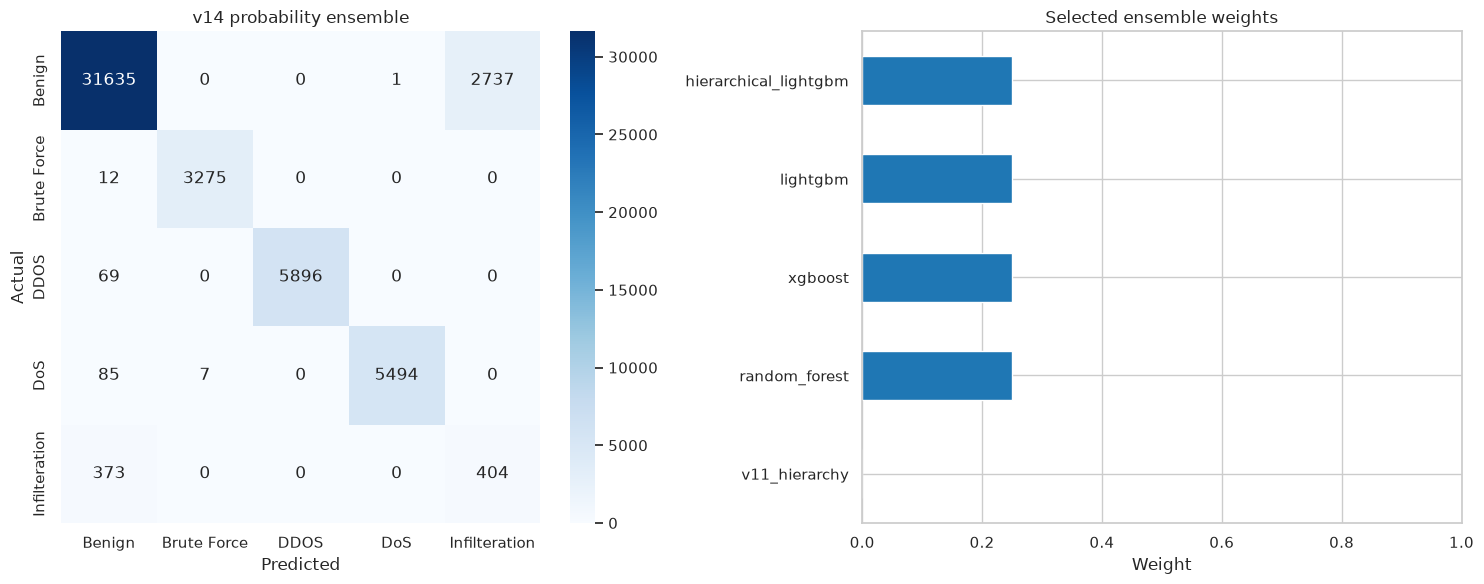

,model,weighted_f1_attacks,macro_f1_attacks,accuracy,infilteration_precision,infilteration_recall,infilteration_f1,benign_to_infilteration_fp,bruteforce_precision,bruteforce_recall,bruteforce_f1,ddos_precision,ddos_recall,ddos_f1,dos_precision,dos_recall,dos_f1
0,v11_champion,0.920264,0.754209,0.901856,0.091271,0.501931,0.154455,3883,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,v13_random_forest,0.956222,0.791517,0.924022,0.105108,0.503218,0.173894,3329,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,v14_probability_ensemble,0.954669,0.797281,0.934304,0.128621,0.519949,0.206228,2737,0.997867,0.996349,0.997108,1.0,0.988433,0.994183,0.999818,0.98353,0.991607


🏃 View run v14_base_v11_hierarchy at: http://mlflow:5000/#/experiments/1/runs/a8b32f5bcfaa4490892c5fee6a87882f
🧪 View experiment at: http://mlflow:5000/#/experiments/1


🏃 View run v14_base_random_forest at: http://mlflow:5000/#/experiments/1/runs/aac73f76e91c40bf8e8aa6b12448d923
🧪 View experiment at: http://mlflow:5000/#/experiments/1


🏃 View run v14_base_xgboost at: http://mlflow:5000/#/experiments/1/runs/0b5bad17233842459fb29df253ae658d
🧪 View experiment at: http://mlflow:5000/#/experiments/1


🏃 View run v14_base_lightgbm at: http://mlflow:5000/#/experiments/1/runs/90044ba81e384cbd90fd53831ccead6b
🧪 View experiment at: http://mlflow:5000/#/experiments/1


🏃 View run v14_base_hierarchical_lightgbm at: http://mlflow:5000/#/experiments/1/runs/44d41f108c4745ae89e43f3c6952bef6
🧪 View experiment at: http://mlflow:5000/#/experiments/1


2026/08/17 15:29:31 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


2026/08/17 15:29:31 INFO mlflow.pyfunc: Validating input example against model signature


🏃 View run v14_cross_model_probability_ensemble_validation at: http://mlflow:5000/#/experiments/1/runs/8f424f3d1a9742b4a5d7ff76798d7b1a
🧪 View experiment at: http://mlflow:5000/#/experiments/1
Validation run: 8f424f3d1a9742b4a5d7ff76798d7b1a
Model URI: models:/m-58088161aaad4cf3ae5e63b09968f0cd
Status: /home/jovyan/work/network-classification/outputs/v14/BENCHMARK_ONLY.md


In [5]:
comparison_df = pd.DataFrame([
    {"model": "v11_champion", **V11_BASELINE},
    {"model": "v13_random_forest", **V13_BASELINE},
    {"model": "v14_probability_ensemble", **metrics},
])
comparison_path = OUTPUT_DIR / "v14_champion_summary.csv"
comparison_df.to_csv(comparison_path, index=False, encoding="utf-8-sig")
late_path = OUTPUT_DIR / "v14_late_holdout_summary.csv"
pd.DataFrame([{"model": "v14_probability_ensemble", **late_metrics}]).to_csv(late_path, index=False, encoding="utf-8-sig")
report_path = OUTPUT_DIR / "v14_classification_report.csv"
pd.DataFrame(classification_report(y_valid, selected_prediction, labels=classes, output_dict=True, zero_division=0)).T.to_csv(report_path, encoding="utf-8-sig")

cm = confusion_matrix(y_valid, selected_prediction, labels=classes)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set(title="v14 probability ensemble", xlabel="Predicted", ylabel="Actual")
weight_values = pd.Series(selected_weights).sort_values()
weight_values.plot.barh(ax=axes[1], color="tab:blue")
axes[1].set(title="Selected ensemble weights", xlabel="Weight", xlim=(0, 1))
plt.tight_layout()
plot_path = OUTPUT_DIR / "v14_confusion_and_weights.png"
fig.savefig(plot_path, dpi=140, bbox_inches="tight")
plt.show()
display(comparison_df)

attachment_columns = X_attachment.columns.tolist()
ensemble_input = X_router_all.iloc[valid_positions].loc[:, router_columns].reset_index(drop=True).copy()
for column in attachment_columns:
    if column != "Dst Port":
        ensemble_input[column] = X_attachment.iloc[valid_positions][column].to_numpy()
ensemble_model = ProbabilityEnsembleIDSModel(
    v11_gate=validation_gate,
    v11_subtype=validation_subtype,
    attachment_models=base_models,
    weights=selected_weights,
    classes=classes,
    router_columns=router_columns,
    attachment_columns=attachment_columns,
    port_map=port_map,
    infilteration_multiplier=selected_multiplier,
)
smoke_prediction = ensemble_model.predict(None, ensemble_input.iloc[:20])[TARGET].to_numpy()
assert np.array_equal(smoke_prediction, selected_prediction[:20])
input_example = ensemble_input.iloc[:5].copy()
output_example = ensemble_model.predict(None, input_example)
signature = infer_signature(input_example, output_example)

notebook_path = cwd / "code_mlflow_pipeline_v14.ipynb"
lineage_sample = processed_sample.iloc[:2000].copy()
numeric = lineage_sample.select_dtypes(include=[np.number]).columns
lineage_sample[numeric] = lineage_sample[numeric].astype(float)
with hypothesis_run(
    run_name="v14_cross_model_probability_ensemble_validation",
    hypothesis_id=HYPOTHESIS_ID, hypothesis=HYPOTHESIS,
    stage="chronological_validation", promotion_status="benchmark_only",
    validation_strategy="class_chronological_80_20_calibration_first_half_late_holdout_second_half",
    notebook=notebook_path.name, data_version=RAW_TRAIN.name,
    feature_schema_version="v11-router-plus-v13-past-rolling-v1",
    code_version=file_sha256(notebook_path),
    extra_tags={
        "validation_cohort_id": VALIDATION_COHORT_ID,
        "strictly_comparable": "true",
        "serving_ready": "false",
        "registry_eligible": "false",
        "comparison_only_reason": "rolling_feature_service_not_implemented",
        "selection_data": "validation_first_half_only",
    },
) as parent_run:
    mlflow.log_params({
        "selected_method": selected_method,
        "selection_tier": selection_tier,
        "infilteration_multiplier": selected_multiplier,
        "base_model_count": len(model_names),
        "weight_candidate_count": len(weight_sets),
        "ensemble_candidate_count": len(search_df),
        "router_feature_count": len(router_columns),
        "attachment_feature_count": len(attachment_columns),
        "train_sample": TRAIN_SAMPLE,
        **{f"weight_{name}": value for name, value in selected_weights.items()},
    })
    mlflow.log_metrics({**{key: float(value) for key, value in metrics.items()}, **{f"late_holdout_{key}": float(value) for key, value in late_metrics.items()}})
    log_dataframe_input(lineage_sample, source=TRAIN_TEMPORAL, name="canonical_temporal_v5_sample", context="ensemble_validation", targets=TARGET)
    for artifact in [base_path, search_path, weights_path, comparison_path, late_path, report_path, plot_path]:
        mlflow.log_artifact(str(artifact))
    mlflow.log_artifact(str(notebook_path), artifact_path="code")
    for row in base_rows:
        with mlflow.start_run(run_name=f"v14_base_{row['model']}", nested=True):
            mlflow.set_tags({"hypothesis_id": HYPOTHESIS_ID, "stage": "base_probability_benchmark"})
            mlflow.log_param("model", row["model"])
            mlflow.log_metrics({key: float(value) for key, value in row.items() if key != "model"})
    model_info = mlflow.pyfunc.log_model(
        name="benchmark_model", python_model=ensemble_model,
        input_example=input_example, signature=signature,
        code_paths=[str(PROJECT_DIR / "src" / "probability_ensemble_model.py"), str(PROJECT_DIR / "src" / "attached_temporal_model.py")],
        metadata={"serving_ready": False, "requires_rolling_features": True, "base_models": model_names},
    )
    validation_run_id = parent_run.info.run_id
    model_uri = model_info.model_uri

status_path = OUTPUT_DIR / "BENCHMARK_ONLY.md"
status_path.write_text(
    "# v14 status: benchmark only\n\n"
    f"- Method: `{selected_method}`; Infilteration multiplier: `{selected_multiplier}`\n"
    f"- Weights: `{json.dumps(selected_weights, ensure_ascii=False)}`\n"
    f"- Weighted/Macro/Accuracy: {metrics['weighted_f1_attacks']:.6f} / {metrics['macro_f1_attacks']:.6f} / {metrics['accuracy']:.6f}\n"
    f"- Infilteration P/R/F1: {metrics['infilteration_precision']:.6f} / {metrics['infilteration_recall']:.6f} / {metrics['infilteration_f1']:.6f}; FP: {int(metrics['benign_to_infilteration_fp'])}\n"
    f"- Validation run: `{validation_run_id}`\n- Model artifact: `{model_uri}`\n"
    "- Registry promotion disabled: online rolling feature service is not implemented.\n",
    encoding="utf-8",
)
print("Validation run:", validation_run_id)
print("Model URI:", model_uri)
print("Status:", status_path)
